In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os
import numpy as np
import scipy

FONT_SIZE_TITLE=14
FONT_SIZE=12

In [2]:
conn = duckdb.connect("../results/results.duckdb")

In [3]:
conn.query("SELECT * FROM experiments WHERE id >= 24;")

┌───────┬─────────────────────┬───────────┬─────────────────┬──────────────┬──────────────┬────────────────────────┐
│  id   │      lakehouse      │  client   │ events_produced │ duration_ns  │ waiting_time │ flush_inlined_duration │
│ int32 │       varchar       │  varchar  │      int32      │    int64     │    int64     │         int64          │
├───────┼─────────────────────┼───────────┼─────────────────┼──────────────┼──────────────┼────────────────────────┤
│    24 │ ducklake-0          │ duckdb    │          836793 │ 300045277499 │            5 │                   NULL │
│    25 │ ducklake-1          │ duckdb    │          752827 │ 300012746645 │            5 │                   NULL │
│    26 │ ducklake-2          │ duckdb    │          737673 │ 300072009842 │            5 │                   NULL │
│    27 │ iceberg-0           │ pyiceberg │          885992 │ 300329066050 │            5 │                   NULL │
│    28 │ iceberg-1           │ pyiceberg │          847827 │ 30

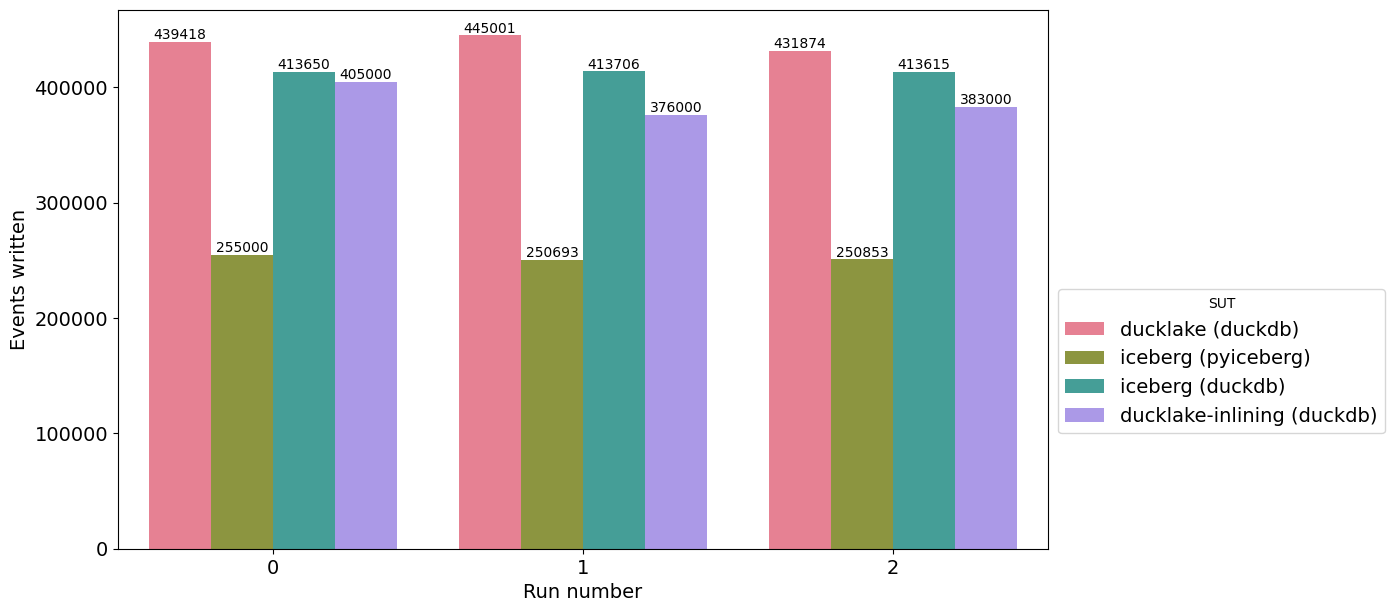

In [4]:
# total_events_consumed_ids = [i for i in range(24,36)]
total_events_consumed_ids = [24,25,26,27,28,29,33,34,35,36,37,38]

total_events_consumed = conn.query("SELECT concat(str_split_regex(experiments.lakehouse, '-[0-9]')[1], ' ', '(', experiments.client, ')') AS lakehouse, " \
                            "str_split_regex(experiments.lakehouse, '-')[-1] AS run_number, " \
                            "COUNT(events.*) AS events_consumed, " \
                            "experiments.client " \
                            "FROM experiments " \
                            "JOIN events ON events.experiment_id = experiments.id " \
                            f"WHERE id IN ({",".join(["?" for _ in range(len(total_events_consumed_ids))])}) " \
                            "GROUP BY experiments.id, experiments.lakehouse, experiments.client " \
                            "ORDER BY experiments.id;", params=total_events_consumed_ids).fetchnumpy()

plt.figure(figsize=(12,7))
ax = plt.subplot()
# ax.set_title("Total number of Kafka events written to each lakehouse after 5 minutes, repeated 3 times", fontsize=FONT_SIZE_TITLE)
ax.set_xlabel("Run number", fontsize=FONT_SIZE+2)
ax.set_ylabel("Events written", fontsize=FONT_SIZE+2)
ax.tick_params(axis="both", which='major', labelsize=FONT_SIZE+2)
sns.barplot(total_events_consumed, x="run_number", y="events_consumed", hue="lakehouse", palette=sns.color_palette("husl", 4))
for container in ax.containers:
    ax.bar_label(container)
ax.legend(title="SUT", bbox_to_anchor=(1, 0.5), fontsize=FONT_SIZE+2)
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/total-batched-events-written.eps", bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


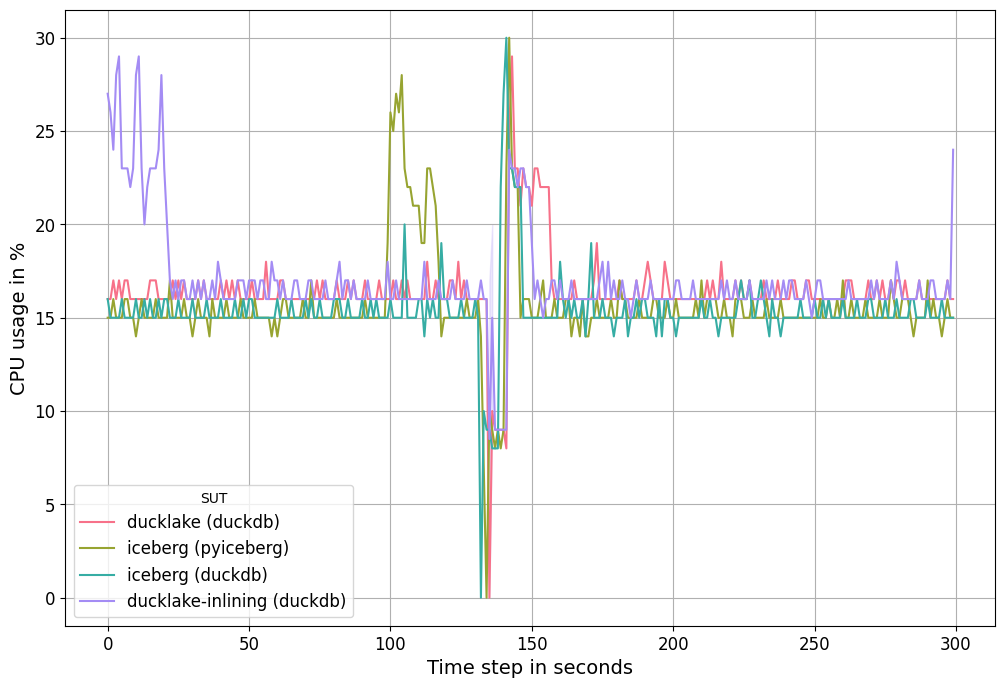

In [ ]:
def get_cpu_percentage(experiment_ids: list[int]):
    return conn.query("SELECT h.id % 300 AS time_step," \
                        "concat(str_split_regex(e.lakehouse, '-[0-9]')[1], ' ', '(', e.client, ')') AS lakehouse, " \
                        "h.cpu_percentage, " \
                        "FROM hardware_metrics AS h " \
                        "JOIN experiments AS e ON e.id = h.experiment_id " \
                        f"WHERE experiment_id IN ({",".join(["?" for _ in range(len(experiment_ids))])});", params=experiment_ids).fetchnumpy()

plt.figure(figsize=(12,8))
ax = plt.subplot()
ax.grid(visible=True)
ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE)
ax.set_xlabel("Time step in seconds", fontsize=FONT_SIZE+2)
ax.set_ylabel("CPU usage in %", fontsize=FONT_SIZE+2)
sns.lineplot(get_cpu_percentage([25,28,37,34]), x="time_step", y="cpu_percentage", hue="lakehouse", ax=ax, palette=sns.color_palette("husl", 4))
plt.legend(loc="best", title="SUT", fontsize=FONT_SIZE)
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/cpu-usage-batched-events.eps", bbox_inches="tight")
plt.show()

## Plot bytes written

In [6]:
def get_bytes_written(experiment_ids: list[int]):
    return conn.query("SELECT h.id % 300 AS time_step, " \
                        "e.id AS experiment_id, " \
                        "concat(str_split_regex(e.lakehouse, '-[0-9]')[1], ' ', '(', e.client, ')') AS lakehouse, " \
                        "COALESCE(h.bytes_written - LAG(h.bytes_written) OVER (ORDER BY h.id), 0) AS bytes_written_clean," \
                        "FROM hardware_metrics as h " \
                        "JOIN experiments AS e ON e.id = h.experiment_id " \
                        f"WHERE experiment_id IN ({",".join(["?" for _ in range(len(experiment_ids))])}) " \
                        "ORDER BY experiment_id;", params=experiment_ids).fetchnumpy()

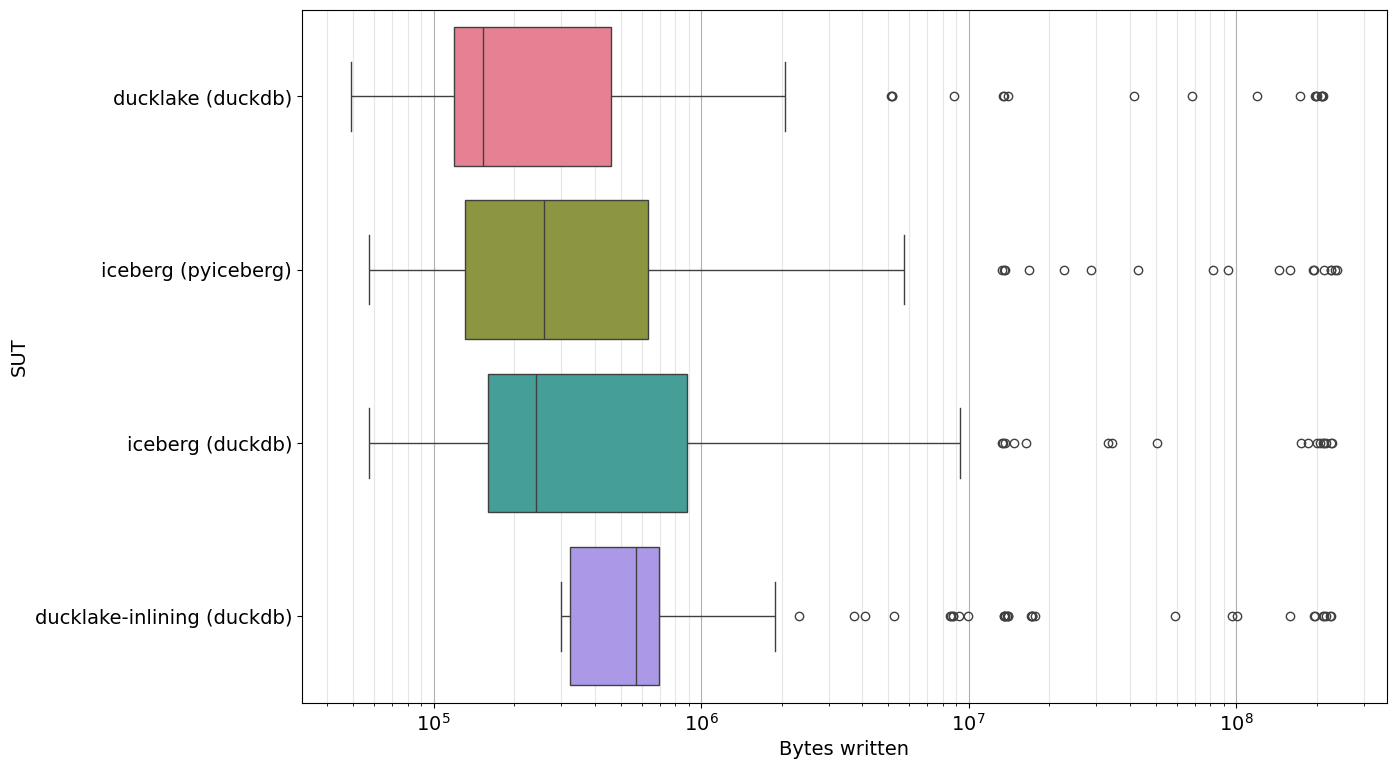

In [7]:
bytes_written_experiment_ids = [25,28,37,34]
# bytes_written_experiment_ids = [24,27,36,33]
# bytes_written_experiment_ids = [26,29,38,35]
bytes_written = get_bytes_written(bytes_written_experiment_ids)

plt.figure(figsize=(14,9))
ax = plt.subplot()
ax.grid()
ax.grid(which="minor", color="0.9")
# ax.set_title("Boxplot of bytes written to disk at every second when inserting individual events to each SUT (warm run)", fontsize=FONT_SIZE_TITLE+2)
ax.set_xlabel("Bytes written", fontsize=FONT_SIZE+2)
ax.tick_params(axis="both", which='major', labelsize=FONT_SIZE+2)
# ax.tick_params(axis="y", labelrotation=30)
ax.set_ylabel("SUT", fontsize=FONT_SIZE+2)
sns.boxplot(bytes_written, x="bytes_written_clean", y="lakehouse", hue="lakehouse", palette=sns.color_palette("husl", len(bytes_written_experiment_ids)), ax=ax, log_scale=True)
# plt.legend(loc="best", title="SUT", bbox_to_anchor=(1, 0.5), fontsize=FONT_SIZE)
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/box-bytes-written-batched.eps", bbox_inches="tight")

plt.show()

### Medians

In [8]:
experiment_ids = bytes_written["experiment_id"]
ducklake_duck_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 25])
iceberg_py_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 28])
ducklake_in_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 37])
iceberg_duck_median = np.median(bytes_written["bytes_written_clean"][experiment_ids == 34])

np.format_float_scientific(ducklake_duck_median), np.format_float_scientific(iceberg_py_median), np.format_float_scientific(ducklake_in_median), np.format_float_scientific(iceberg_duck_median)

('1.536e+05', '2.58048e+05', '5.7344e+05', '2.41664e+05')

### Interquartile ranges

In [9]:
experiment_ids = bytes_written["experiment_id"]
ducklake_duck_iqr = scipy.stats.iqr(bytes_written["bytes_written_clean"][experiment_ids == 25])
iceberg_py_iqr = scipy.stats.iqr(bytes_written["bytes_written_clean"][experiment_ids == 28])
ducklake_in_iqr = scipy.stats.iqr(bytes_written["bytes_written_clean"][experiment_ids == 37])
iceberg_duck_iqr = scipy.stats.iqr(bytes_written["bytes_written_clean"][experiment_ids == 34])

np.format_float_scientific(ducklake_duck_iqr), np.format_float_scientific(iceberg_py_iqr), np.format_float_scientific(ducklake_in_iqr), np.format_float_scientific(iceberg_duck_iqr)

('3.40992e+05', '5.0176e+05', '3.71712e+05', '7.2704e+05')

## Plot read and write times

In [10]:
def get_write_times(experiment_ids: list[int]):
    return conn.query("SELECT ev.trip_id, " \
                        "ex.id AS experiment_id, " \
                        "concat(str_split_regex(ex.lakehouse, '-[0-9]')[1], ' ', '(', ex.client, ')') AS lakehouse, " \
                        "ev.write_duration_ns/1e9 AS write_time " \
                        "FROM events AS ev " \
                        "JOIN experiments AS ex ON ex.id = ev.experiment_id " \
                        f"WHERE ex.id IN ({",".join(["?" for _ in range(len(experiment_ids))])}) AND ev.write_duration_ns NOT NULL " \
                        "ORDER BY ex.id;", params=experiment_ids).fetchnumpy()

write_times = get_write_times([25,28,37,34])

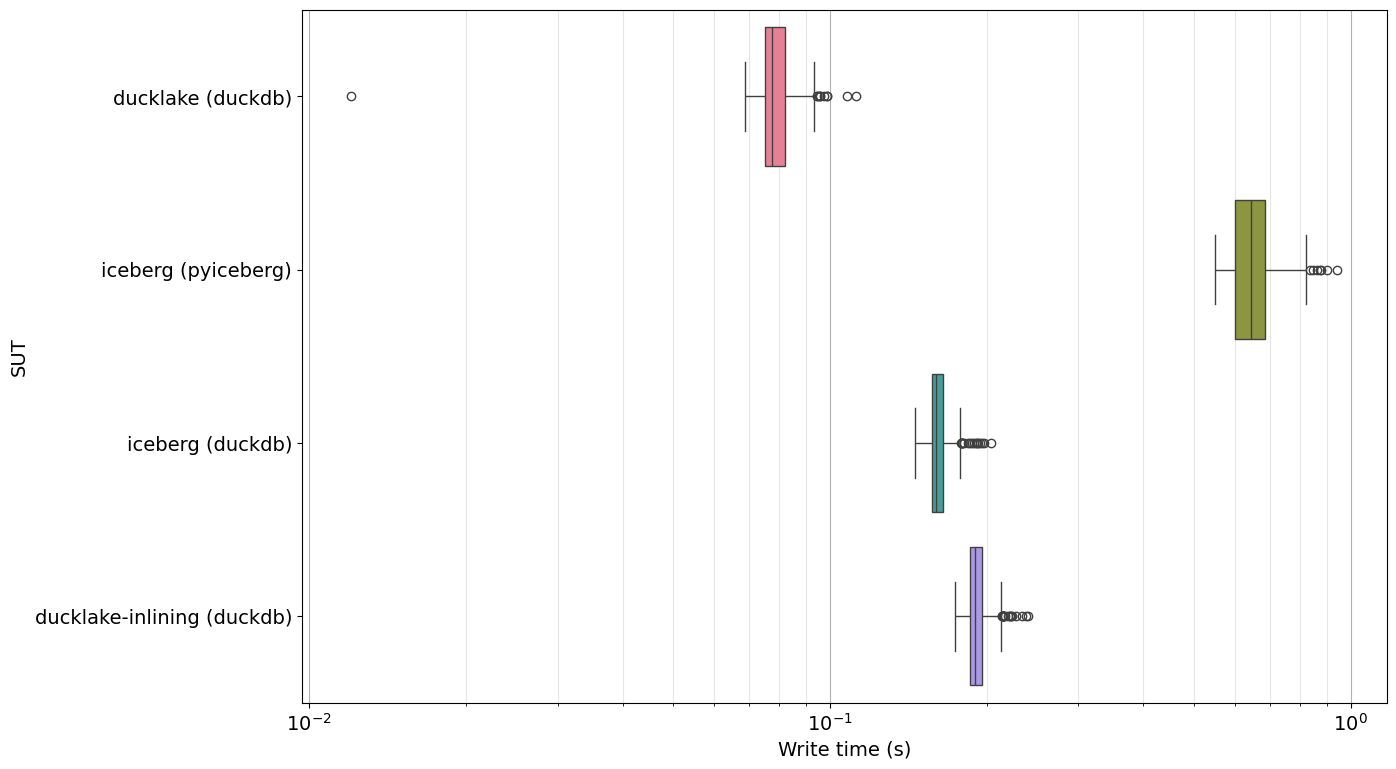

In [11]:
plt.figure(figsize=(14,9))
ax = plt.subplot()
ax.grid()
ax.grid(which="minor", color="0.9")
# ax.set_title("Box plots of the time spent writing individual events for each SUT, in seconds", fontsize=FONT_SIZE_TITLE+2)
ax.set_xlabel("Write time (s)", fontsize=FONT_SIZE+2)
ax.set_ylabel("SUT", fontsize=FONT_SIZE+2)
ax.tick_params(axis="both", which='major', labelsize=FONT_SIZE+2)
sns.boxplot(write_times, x="write_time", y="lakehouse", hue="lakehouse", palette=sns.color_palette("husl", 4), ax=ax, log_scale=True)
# ax.legend(loc="best", title="SUT", fontsize=FONT_SIZE+2)
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/box-write-times-batched.eps", bbox_inches="tight")
plt.show()

### Medians

In [12]:
(np.format_float_scientific(np.nanmedian(get_write_times([25])["write_time"].data)),
 np.format_float_scientific(np.nanmedian(get_write_times([28])["write_time"].data)),
 np.format_float_scientific(np.nanmedian(get_write_times([37])["write_time"].data)),
 np.format_float_scientific(np.nanmedian(get_write_times([34])["write_time"].data)),
)

('7.74388875e-02', '6.44841503e-01', '1.89746488e-01', '1.60085586e-01')

### Interquartile ranges

In [13]:
(np.format_float_scientific(scipy.stats.iqr(get_write_times([25])["write_time"])),
 np.format_float_scientific(scipy.stats.iqr(get_write_times([28])["write_time"])),
 np.format_float_scientific(scipy.stats.iqr(get_write_times([37])["write_time"])),
 np.format_float_scientific(scipy.stats.iqr(get_write_times([34])["write_time"])),
)

('6.941583750000008e-03',
 '8.469498649999996e-02',
 '1.0624622250000021e-02',
 '8.188870250000008e-03')

In [14]:
def get_read_times(experiment_ids: list[int]):
    return conn.query("SELECT ev.trip_id, " \
                        "ex.id AS experiment_id, " \
                        "concat(str_split_regex(ex.lakehouse, '-[0-9]')[1], ' ', '(', ex.client, ')') AS lakehouse, " \
                        "ev.read_duration_ns/1e9 AS read_time, " \
                        "FROM events AS ev " \
                        "JOIN experiments AS ex ON ex.id = ev.experiment_id " \
                        f"WHERE ex.id IN ({",".join(["?" for _ in range(len(experiment_ids))])}) " \
                        "ORDER BY ex.id;", params=experiment_ids).fetchnumpy()

read_times = get_read_times([25,28,37,34])

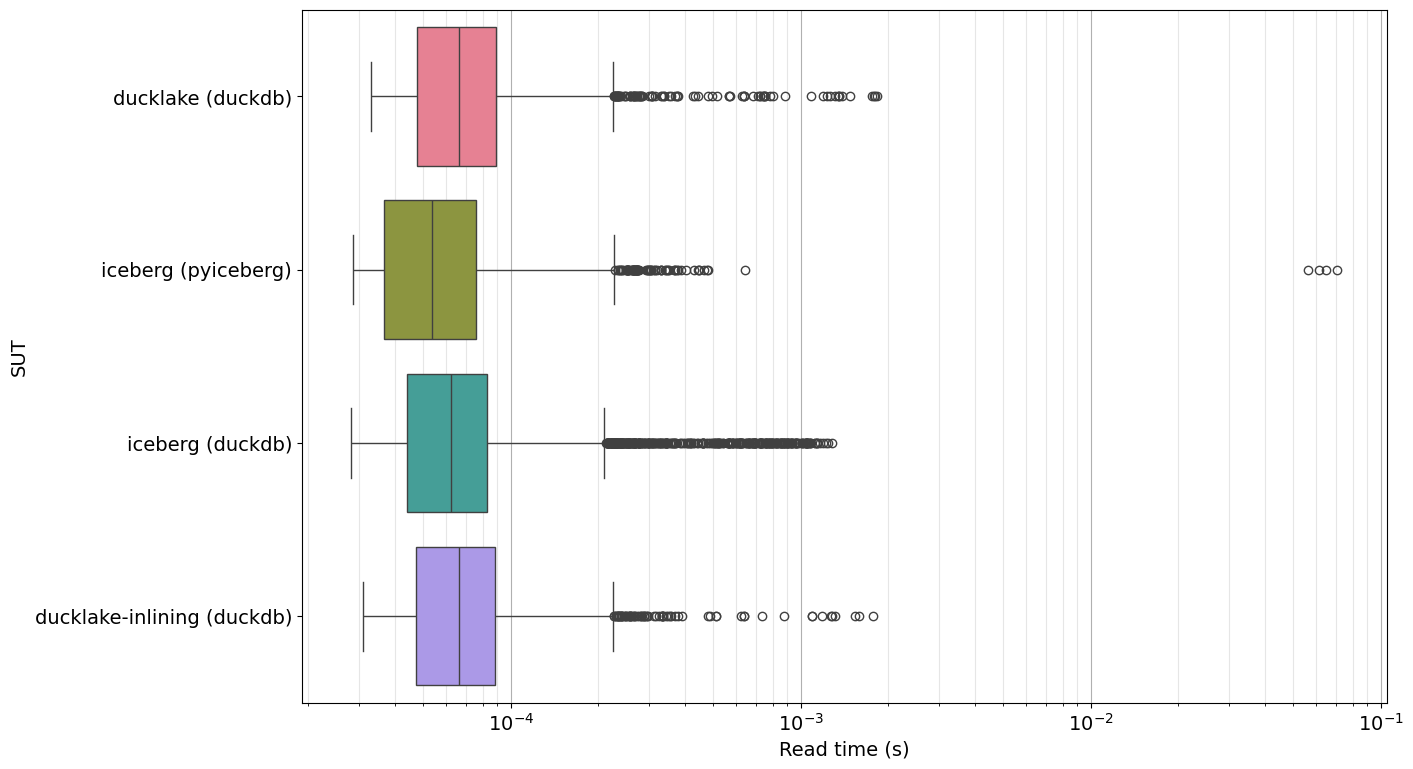

In [19]:
plt.figure(figsize=(14,9))
ax = plt.subplot()
ax.grid()
ax.grid(which="minor", color="0.9")
# ax.set_title("Box plots of the time spent reading individual events from Kafka before inserting them to the SUT, in seconds", fontsize=FONT_SIZE_TITLE+2)
ax.set_xlabel("Read time (s)", fontsize=FONT_SIZE+2)
ax.set_ylabel("SUT", fontsize=FONT_SIZE+2)
ax.tick_params(axis="both", which='major', labelsize=FONT_SIZE+2)
sns.boxplot(read_times, x="read_time", y="lakehouse", hue="lakehouse", palette=sns.color_palette("husl", 4), ax=ax, log_scale=True)
# ax.legend(title="SUT", fontsize=FONT_SIZE+2)
plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/box-read-times-batched.eps", bbox_inches="tight")
plt.show()

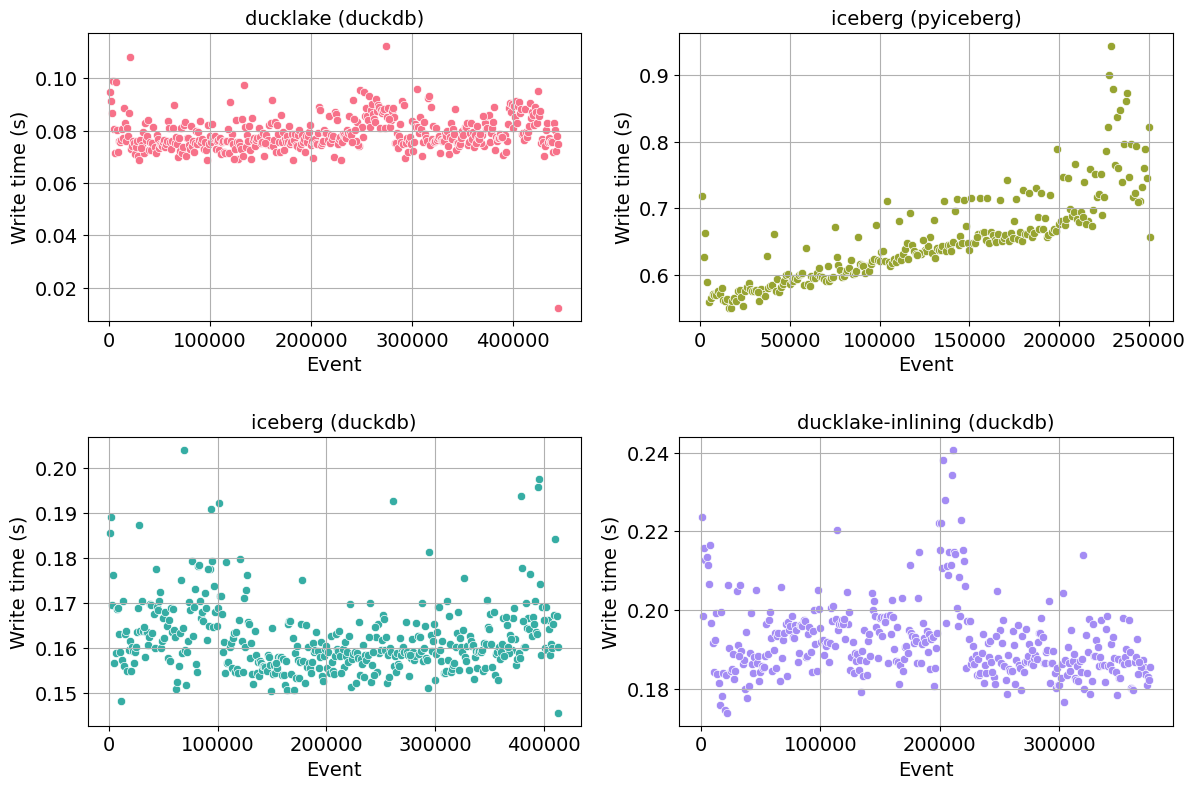

In [ ]:
color_palette = sns.color_palette("husl", 4)
# plt.figure(figsize=(30,15))
fig, ax = plt.subplots(2,2,figsize=(14,9))
plt.subplots_adjust(hspace=0.4)
# write_time_comp = [get_read_and_write_times([i]) for i in range(2,12,3)]
# fig.suptitle("Time spent writing each event to DuckLake (top) and Iceberg (bottom) in seconds", fontsize=FONT_SIZE_TITLE+2)
for i, (axis, experiment_id) in enumerate(zip(ax.flatten(), np.unique(write_times["experiment_id"], sorted=True))):
    axis.grid()
    axis.set_xlabel("Event", fontsize=FONT_SIZE+2)
    axis.set_ylabel("Write time (s)", fontsize=FONT_SIZE+2)
    axis.tick_params(axis="both", which='major', labelsize=FONT_SIZE+2)
    exp_data = get_write_times([int(experiment_id)])
    sns.scatterplot(exp_data, x="trip_id", y="write_time", color=color_palette[i], ax=axis)
    axis.set_title(np.unique(exp_data["lakehouse"])[0], fontsize=FONT_SIZE+2)

# ax.set_yscale("log")
# sns.scatterplot(read_and_write_ducklake, x="trip_id", y="write_time", facecolor=color_palette[0], ax=ax[0])
# sns.scatterplot(read_and_write_iceberg, x="trip_id", y="write_time", facecolor=color_palette[1], ax=ax[1])
# plt.savefig("/home/vinicius/drive/RU/Master/2526/thesis/Master_Thesis/imgs/scatter-write-times-over-time-batched.eps", bbox_inches="tight")
plt.show()

### Inlining

In [17]:
conn.query("SELECT flush_inlined_duration/1e9 FROM experiments WHERE lakehouse LIKE 'ducklake-inlining%' AND id >= 36;")

┌─────────────────────────────────────────┐
│ (flush_inlined_duration / 1000000000.0) │
│                 double                  │
├─────────────────────────────────────────┤
│                             2.286785947 │
│                             1.992167419 │
│                             1.973862601 │
└─────────────────────────────────────────┘